### Tutorial 1 – Scalability and Synchronization


##### Task-1: Scaling of a Computer System

We create a simple model of a computer system. The following is a simple example from queuing theory. We assume that new jobs for the computer system come in with a constant rate of $\alpha$ and are added to a waiting list. We also assume that the process is without memory, that is, incoming jobs are statistically independent from each other. Therefore, we model the incoming jobs as a Poisson process. The probability that $i$ jobs arrive within a given time interval $\Delta t$ is given by:




$P(X = i) = \frac{e^{-\lambda}\lambda^i}{i!}$

for $\lambda = \alpha \Delta t$. In the following we simply set $\Delta t = 1$.


a) Plot $P(X = i)$ for a reasonable interval of $X$ and $\alpha \in \{0.01, 0.1, 0.5, 1\}$.

In [ ]:
import math
import random
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import poisson


#for verification only
def poisson_pmf(i, alpha):
    """P(X=i) for Poisson(lamda=alpha), with delta(t)=1."""
    return (math.exp(-alpha) * (alpha ** i)) / math.factorial(i)
#for verification only
def sample_poisson(alpha):
    L = math.exp(-alpha)
    k, p = 0, 1.0
    while p > L:
        k += 1
        p *= random.random()
    return k - 1


def sample_incoming_jobs(alpha, size=1):
    """Samples number of incoming jobs from a Poisson distribution."""
    return np.random.poisson(alpha, size)

alpha_b = 0.1
samples = sample_incoming_jobs(alpha_b, size=1000)

print(f"Sampling 1000 values from Poisson(alpha={alpha_b})")
print(f"Mean = {samples.mean():.4f}  (expected ~ {alpha_b})")
print(f"Variance = {samples.var():.4f}  (expected ~ {alpha_b})")

Sampling 1000 values from Poisson(alpha=0.1)
Mean = 0.0970  (expected ≈ 0.1)
Variance = 0.0956  (expected ≈ 0.1)


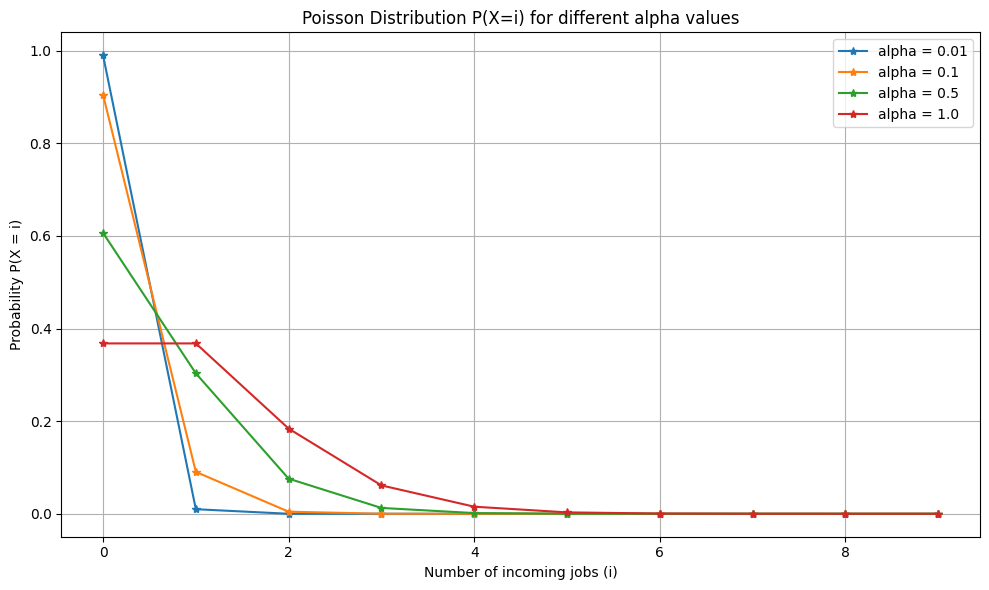

In [4]:
alphas = [0.01, 0.1, 0.5, 1.0]
x = np.arange(0, 10)

plt.figure(figsize=(10, 6))
for alpha in alphas:
    pmf = poisson.pmf(x, alpha)
    plt.plot(x, pmf, '*-', label=f'alpha = {alpha}')

plt.title('Poisson Distribution P(X=i) for different alpha values')
plt.xlabel('Number of incoming jobs (i)')
plt.ylabel('Probability P(X = i)')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

b) Implement a program that samples numbers of incoming jobs from P (X = i)

In [ ]:
def sample_incoming_jobs(alpha, size=1):
    """Samples number of incoming jobs from a Poisson distribution."""
    return np.random.poisson(alpha, size)

alpha_b = 0.1
samples = sample_incoming_jobs(alpha_b, size=1000)

print(f"Sampling 1000 values from Poisson(alpha={alpha_b})")
print(f"  Mean= {samples.mean():.4f}  (expected ~ {alpha_b})")
print(f"  Variance = {samples.var():.4f}  (expected ~ {alpha_b})")

Sampling 1000 values from Poisson(alpha=0.1)
  Mean= 0.1120  (expected ≈ 0.1)
  Variance = 0.1095  (expected ≈ 0.1)


c) Implement a model that iterates over these two phases: calculate and manage new incoming jobs, then operate on the current job (one at a time). Generate a sample of 2000 time steps for $\alpha$ = 0.1 and a processing duration of 4 steps per job. What is the average length of the waiting list?

In [6]:
def simulate_queue(alpha, num_steps, processing_duration):
    """
    Single-server queue simulation.
    Returns array of waiting-list lengths at each time step.
    """
    queue_lengths = np.zeros(num_steps, dtype=int)
    waiting_jobs  = 0
    time_until_free = 0

    for t in range(num_steps):
        waiting_jobs += sample_incoming_jobs(alpha)[0]   # arrivals

        if time_until_free == 0 and waiting_jobs > 0:       # start new job
            waiting_jobs -= 1
            time_until_free = processing_duration

        if time_until_free > 0:                             # tick server
            time_until_free -= 1

        queue_lengths[t] = waiting_jobs

    return queue_lengths


alpha_c, proc_c, steps_c = 0.1, 4, 2000
ql_c = simulate_queue(alpha_c, steps_c, proc_c)

print(f"Parameters: alpha={alpha_c}, processing={proc_c} steps, {steps_c} time steps")
print(f"  Average queue length : {ql_c.mean():.4f}")
print(f"  Max queue length     : {ql_c.max()}")

Parameters: alpha=0.1, processing=4 steps, 2000 time steps
  Average queue length : 0.1385
  Max queue length     : 4


d) Modify your program so that you can repeat the 2000-step simulation many times and average the resulting queue lengths. For each rate $\alpha \in$ [0.005, 0.25] in steps of 0.005, run the model 200 independent times, compute the average queue length for each run, then average these 200 values to obtain one final number per $\alpha$. Plot this final average as a function of $\alpha$. Discuss what this reveals about the system’s behavior

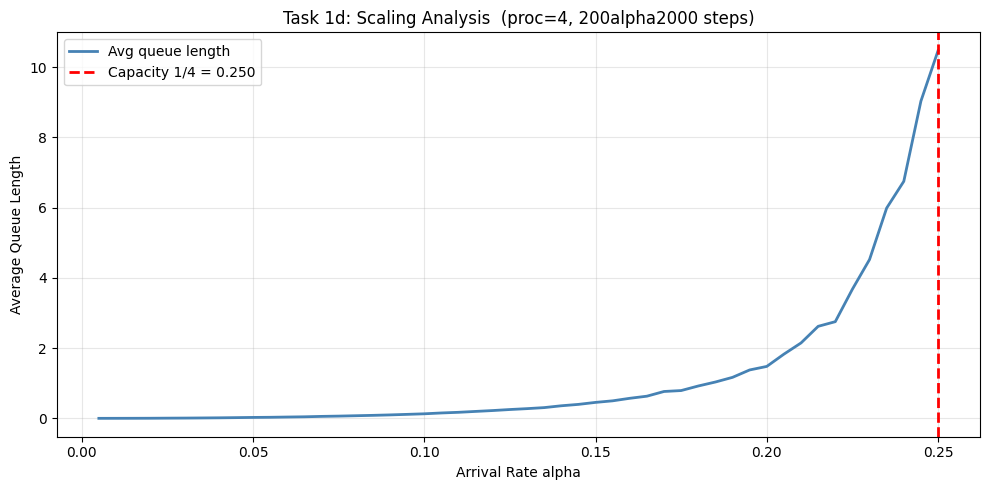

Capacity = 1/4 = 0.250
Below capacity → queue stays short; above → queue diverges (phase transition).


In [ ]:
alpha_values_4 = np.arange(0.005, 0.255, 0.005)
proc_dur_4 = 4
num_steps = 2000
n_sims = 200

avg_ql_4 = []
for alpha in alpha_values_4:
    runs = [np.mean(simulate_queue(alpha, num_steps, proc_dur_4))
            for m in range(n_sims)]
    avg_ql_4.append(np.mean(runs))

capacity_4 = 1 / proc_dur_4

plt.figure(figsize=(10, 5))
plt.plot(alpha_values_4, avg_ql_4, linewidth=2, color='steelblue',
         label='Avg queue length')
plt.axvline(capacity_4, color='red', linestyle='--', linewidth=2,
            label=f'Capacity 1/{proc_dur_4} = {capacity_4:.3f}')
plt.xlabel('Arrival Rate alpha')
plt.ylabel('Average Queue Length')
plt.title(f'Task 1d: Scaling Analysis  (proc={proc_dur_4}, {n_sims}alpha{num_steps} steps)')
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('task1d_scaling_analysis_duration4.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"Capacity = 1/{proc_dur_4} = {capacity_4:.3f}")
print("Below capacity -> queue stays short; above -> queue diverges (phase transition).")

e) Do the same for a processing duration of only 2 steps per job with rates $\alpha \in$ [0.005, 0.5] in steps of 0.005. Compare the two plots and discuss the change in the system’s behavior as a result of these changes.

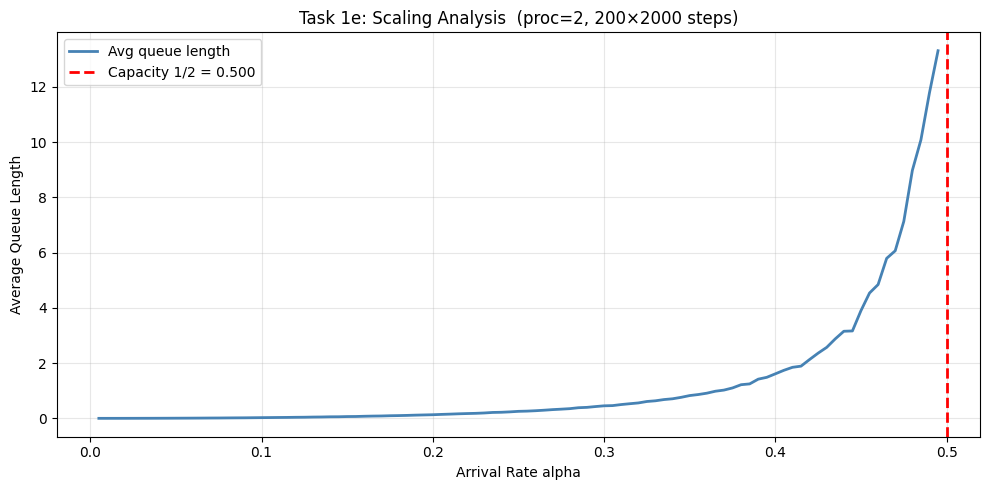

Capacity = 1/2 = 0.500
Below capacity → queue stays short; above → queue diverges (phase transition).


In [8]:
alpha_values_2 = np.arange(0.005, 0.5, 0.005)
proc_dur_2 = 2
num_steps = 2000
n_sims = 200

avg_ql_2 = []
for alpha in alpha_values_2:
    runs = [np.mean(simulate_queue(alpha, num_steps, proc_dur_2))
            for m in range(n_sims)]
    avg_ql_2.append(np.mean(runs))

capacity_2 = 1 / proc_dur_2

plt.figure(figsize=(10, 5))
plt.plot(alpha_values_2, avg_ql_2, linewidth=2, color='steelblue',
         label='Avg queue length')
plt.axvline(capacity_2, color='red', linestyle='--', linewidth=2,
            label=f'Capacity 1/{proc_dur_2} = {capacity_2:.3f}')
plt.xlabel('Arrival Rate alpha')
plt.ylabel('Average Queue Length')
plt.title(f'Task 1e: Scaling Analysis  (proc={proc_dur_2}, {n_sims}×{num_steps} steps)')
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('task1e_scaling_analysis_duration2.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"Capacity = 1/{proc_dur_2} = {capacity_2:.3f}")
print("Below capacity -> queue stays short; above -> queue diverges (phase transition).")

##### Task-2: Synchronization of a Swarm

Swarm systems are asynchronous systems. There is no central clock that could be accessed by
everyone. If a swarm needs to act in synchrony, it has to explicitly synchronize first. An example
of a biological system that shows synchronization is a population of fireflies (see Fig. 1)


In the following we create a simple model of such a firefly population. The population is scattered randomly over a $1 \times 1$ square (uniform distribution). We assume that fireflies are stationary and can only perceive local neighbors in their vicinity. We say two fireflies are within the vicinity of each other if the distance between them is smaller than $r$. Hence, there is a virtual disc centered at each firefly’s position and every other firefly located within that disc is considered a neighbor.

The fireflies flash in cycles. We define the cycle length by $L = 50$ time steps. We initialize the fireflies to uniformly randomly distributed clock cycles (i.e., not synchronized). The firefly flashes for $L/2$ steps followed by $L/2$ steps of not flashing. This holds except when the firefly attempts to correct its cycle to synchronize. In the time step after it has started to flash it checks its neighbors and tests whether the majority of them is actually already flashing. If so, the firefly corrects its clock by adding 1, that is, it is decreasing the current flashing cycle from $L/2$ to $L/2 - 1$ steps and will consequently flash 1 step earlier next time.

a) Implement the model for swarm size $N = 150$ and cycle length $L = 50$. Calculate the average number of neighbors per firefly for vicinity distances $r \in \{0.05, 0.1, 0.5, 1.4\}$. Plot the number of currently flashing fireflies over time for vicinity distances $r \in \{0.05, 0.1, 0.5, 1.4\}$ for 5000 time steps each. When plotting the number of currently flashing flies, make sure you plot the full interval of $[0, 150]$ for the vertical axis.

b) Extend your model to determine the minimum and maximum number of concurrently flashing fireflies during the very last cycle (last $L = 50$ time steps starting from $t = 4950$). By subtracting the minimum from the maximum you get twice the amplitude of the flash cycle. Average the measured amplitudes over 50 samples each (50 independent simulation runs with 5000 time steps each) and plot them over vicinities $r \in [0.025, 1.4]$ in steps of 0.025. What seems to be a good choice for the vicinity and the swarm density? What do low amplitudes tell us about synchronization, and what do high amplitudes reveal?

     r    avg_nbrs    last_min    last_max   amplitude
-------------------------------------------------------
  0.05        0.95          54          96          42
  0.10        4.29          38         108          70
  0.50       76.40           0         150         150
  1.40      149.00          38         112          74


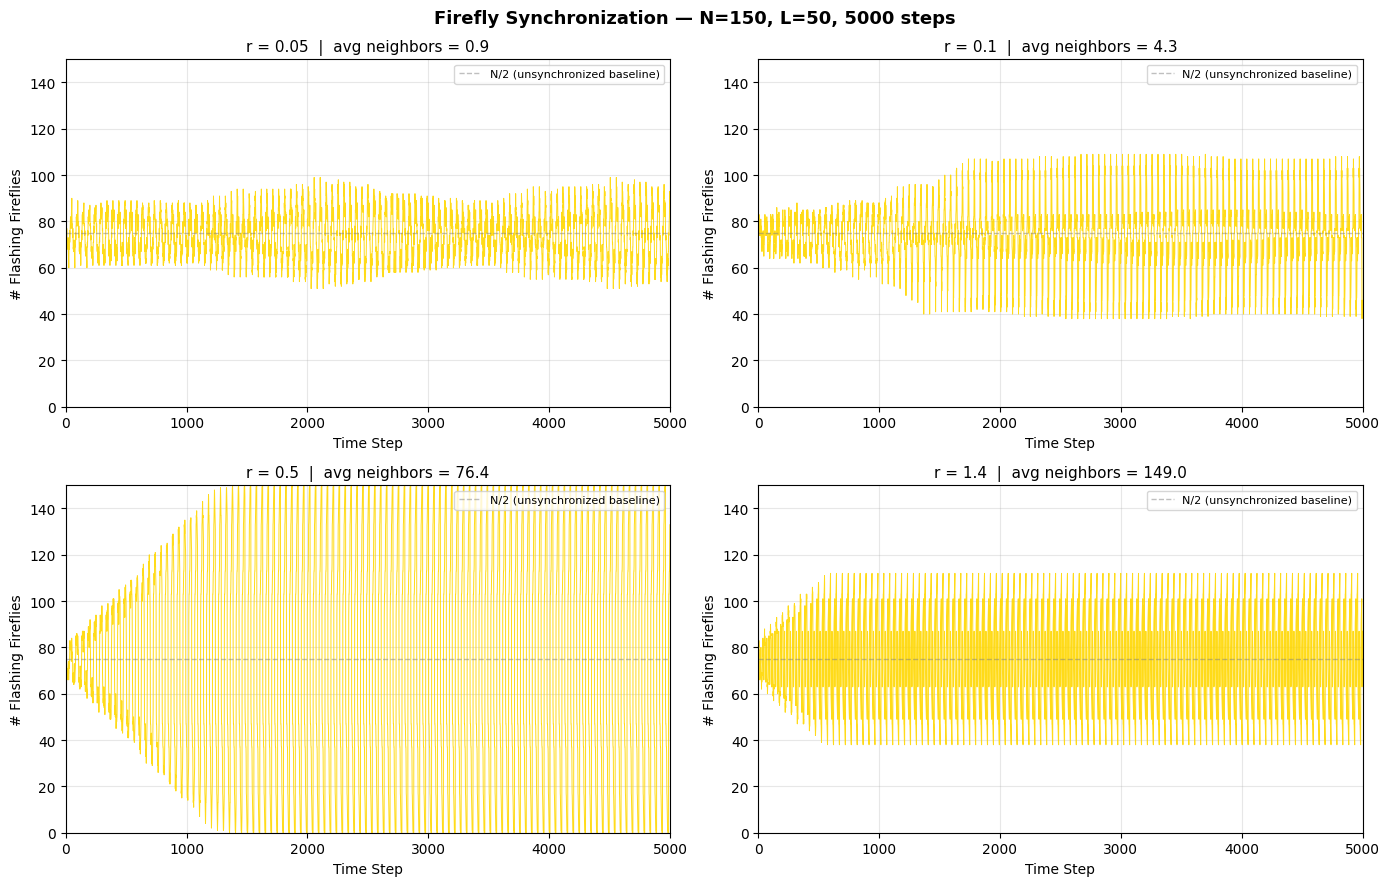

Saved: task2a_flashing_patterns.png
Task 2b: 56 radii × 50 runs = 2800 simulations
  10/56 | r=0.250 | amp=121.0 | 40s elapsed | ~184s left


KeyboardInterrupt: 

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import time

# ============================================================================
# CORE SIMULATION — sparse neighbor lists, O(N/L) work per step
# ============================================================================

def simulate_fireflies(N=150, L=50, r=0.1, num_steps=5000):
    """
    Returns (flashing_counts [num_steps], avg_neighbors float)
    
    Key insight: positions are FIXED, so precompute neighbor lists ONCE.
    Then each step only checks ~N/L ~ 3 'just-started' fireflies.
    """
    half = L // 2  # = 25, fixed forever — never modify this

    # --- Fixed random positions ---
    pos = np.random.uniform(0, 1, (N, 2))

    # --- Precompute neighbor index lists (done ONCE per simulation) ---
    d = np.sqrt(((pos[:, None] - pos[None, :])**2).sum(-1))  # (N, N)
    np.fill_diagonal(d, np.inf)                               # exclude self
    nbrs = [np.where(d[i] < r)[0] for i in range(N)]         # list of arrays
    nb_counts = np.array([len(nb) for nb in nbrs])            # (N,) int

    # --- Random initial clocks, uniform [0, L-1] ---
    clocks = np.random.randint(0, L, N)

    counts = np.empty(num_steps, dtype=np.int32)

    for t in range(num_steps):
        # Snapshot of who is flashing RIGHT NOW (before any updates)
        flashing = clocks < half          # (N,) bool
        counts[t] = flashing.sum()

        # ---- Correction phase ----
        # Only ~N/L ~ 3 fireflies just started this step -> tiny inner loop
        for i in np.where(clocks == 0)[0]:
            n = nb_counts[i]
            if n > 0 and flashing[nbrs[i]].sum() > n / 2:
                clocks[i] += 1  # add 1: shortens THIS flash phase by 1 step

        # ---- Advance all clocks simultaneously ----
        clocks = (clocks + 1) % L

    return counts, nb_counts.mean()


# ============================================================================
# TASK 2a
# ============================================================================

def task_2a(N=150, L=50, num_steps=5000):
    radii = [0.05, 0.1, 0.5, 1.4]

    fig, axes = plt.subplots(2, 2, figsize=(14, 9))
    axes = axes.flatten()

    print(f"{'r':>6}  {'avg_nbrs':>10}  {'last_min':>10}  {'last_max':>10}  {'amplitude':>10}")
    print("-" * 55)

    for idx, r in enumerate(radii):
        counts, avg_nb = simulate_fireflies(N, L, r, num_steps)

        last_min = counts[-L:].min()
        last_max = counts[-L:].max()
        amplitude = last_max - last_min #
        print(f"{r:>6.2f}  {avg_nb:>10.2f}  {last_min:>10}  {last_max:>10}  {amplitude:>10}")

        ax = axes[idx]
        ax.plot(counts, color='gold', lw=0.7, alpha=0.9)
        ax.axhline(N // 2, color='gray', ls='--', lw=1, alpha=0.5,
                   label='N/2 (unsynchronized baseline)')
        ax.set_ylim(0, N)
        ax.set_xlim(0, num_steps)
        ax.set_xlabel('Time Step')
        ax.set_ylabel('# Flashing Fireflies')
        ax.set_title(f'r = {r}  |  avg neighbors = {avg_nb:.1f}', fontsize=11)
        ax.legend(fontsize=8, loc='upper right')
        ax.grid(alpha=0.3)

    plt.suptitle(f'Firefly Synchronization — N={N}, L={L}, {num_steps} steps',
                 fontsize=13, fontweight='bold')
    plt.tight_layout()
    plt.savefig('task2a_flashing_patterns.png', dpi=150, bbox_inches='tight')
    plt.show()
    print("Saved: task2a_flashing_patterns.png")


# ============================================================================
# TASK 2b
# ============================================================================

def task_2b(N=150, L=50, num_steps=5000, num_runs=50):
    radii = np.arange(0.025, 1.425, 0.025)  # 56 values
    avg_amps = []

    total = len(radii) * num_runs
    print(f"Task 2b: {len(radii)} radii × {num_runs} runs = {total} simulations")

    t0 = time.time()
    for idx, r in enumerate(radii):
        amps = []
        for k in range(num_runs):
            fc, l = simulate_fireflies(N, L, r, num_steps)
            amps.append(int(fc[-L:].max() - fc[-L:].min()))
        avg_amps.append(np.mean(amps))

        if (idx + 1) % 10 == 0:
            elapsed = time.time() - t0
            done = (idx + 1) * num_runs
            eta = elapsed / done * (total - done)
            print(f"  {idx+1:2d}/{len(radii)} | r={r:.3f} | "
                  f"amp={avg_amps[-1]:.1f} | "
                  f"{elapsed:.0f}s elapsed | ~{eta:.0f}s left")

    avg_amps = np.array(avg_amps)
    r_crit = np.sqrt(np.log(N) / (np.pi * N))

    fig, ax = plt.subplots(figsize=(12, 6))
    ax.plot(radii, avg_amps, 'o-', color='steelblue', ms=4, lw=2,
            label=f'Avg amplitude ({num_runs} runs/radius)')
    ax.axvline(r_crit, color='red', ls='--', lw=1.5, alpha=0.8,
               label=f'Theoretical connectivity threshold r* ≈ {r_crit:.3f}')
    ax.axhline(0, color='gray', ls=':', lw=1, alpha=0.4)
    ax.set_xlabel('Vicinity Radius r', fontsize=12)
    ax.set_ylabel('Flash Amplitude (max - min over last L steps)', fontsize=12)
    ax.set_title(f'Synchronization Quality vs Vicinity Radius\n'
                 f'N={N}, L={L}, {num_runs} runs alpha {num_steps} steps each',
                 fontsize=13)
    ax.legend(fontsize=11)
    ax.grid(alpha=0.3)
    plt.tight_layout()
    plt.savefig('task2b_amplitude_vs_radius.png', dpi=150, bbox_inches='tight')
    plt.show()
    print("Saved: task2b_amplitude_vs_radius.png")


# ============================================================================
# MAIN
# ============================================================================

if __name__ == "__main__":
    task_2a()
    task_2b()